In [43]:
import pandas as pd
import numpy as np

import seaborn as sns

In [44]:
WRITE_FILES = False

In [45]:
working_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy'

## IMU Downsampling (currently disabled)
- IMU data was recorded at 200hz.
- Because of the high frequency of this data, adding deltas (between 1000 and 1100 microseconds) were not significant to cause Kimera-VIO to crash.
- Will now modify raw data and change it to 100 hz.

In [46]:
df = pd.read_csv(working_dir + '/mav0_euroc/imu0/data.csv')

In [47]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")
# df.head(5)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1413393212225760512,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1413393212230760448,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1413393212235760384,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1413393212240760576,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1413393212245760512,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173


In [48]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].astype('float64')

In [49]:
# df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22800 entries, 0 to 22799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #timestamp [ns]      22800 non-null  float64
 1   w_RS_S_x [rad s^-1]  22800 non-null  float64
 2   w_RS_S_y [rad s^-1]  22800 non-null  float64
 3   w_RS_S_z [rad s^-1]  22800 non-null  float64
 4   a_RS_S_x [m s^-2]    22800 non-null  float64
 5   a_RS_S_y [m s^-2]    22800 non-null  float64
 6   a_RS_S_z [m s^-2]    22800 non-null  float64
dtypes: float64(7)
memory usage: 1.2 MB


In [50]:
# Check the deltas.
orig_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [51]:
original_rate = 200
reduction_factor = 1
# print("The frequency will be reduced to:", original_rate/reduction_factor)

The frequency will be reduced to: 200.0


In [52]:
# Reducing frequency
df = df.iloc[::reduction_factor]

In [53]:
# df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22800 entries, 0 to 22799
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #timestamp [ns]      22800 non-null  float64
 1   w_RS_S_x [rad s^-1]  22800 non-null  float64
 2   w_RS_S_y [rad s^-1]  22800 non-null  float64
 3   w_RS_S_z [rad s^-1]  22800 non-null  float64
 4   a_RS_S_x [m s^-2]    22800 non-null  float64
 5   a_RS_S_y [m s^-2]    22800 non-null  float64
 6   a_RS_S_z [m s^-2]    22800 non-null  float64
dtypes: float64(7)
memory usage: 1.2 MB


In [54]:
# Check deltas after downsampling.
new_deltas = np.unique(np.diff(df['#timestamp [ns]']), return_counts=True)

In [55]:
#Since we have reduced the frequency, we should get a fractional value when we divide the original deltas by the new deltas
# orig_deltas[0] / new_deltas[0]

array([1., 1.])

In [56]:
# df.head(10)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1.413393e+18,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1.413393e+18,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1.413393e+18,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1.413393e+18,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1.413393e+18,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173
5,1.413393e+18,-0.058643,0.024435,0.100531,9.177390,-0.890771,-2.582418
6,1.413393e+18,-0.005585,0.009076,0.113795,9.299973,-1.234003,-2.476179
7,1.413393e+18,0.037001,0.013265,0.100531,9.586000,-0.817221,-2.745862
8,1.413393e+18,0.061436,0.023736,0.091455,9.275456,0.073550,-2.582418
9,1.413393e+18,0.044680,0.017453,0.076794,9.536967,0.498505,-2.688657


In [57]:
max_nano_seconds_to_add = max(np.unique(np.diff(df['#timestamp [ns]'])))

In [58]:
# max_nano_seconds_to_add

np.float64(5000192.0)

## Introducing Minor Variation (jitter) in IMU Timestamps

- 1,000,000 ns = 1 ms
- 5,000,000 ns = 5 ms (current delta)
- Our data is originally at 200Hz frequency so we can introdue at most 5,000,000 ns (5ms) jitter.
- In a worst case scenario, we can have 5,00,000 ns being subtracted and then for the next data point, we we can add 5,00,000 ns, leaving a max delta of 15,000,000 ns = 15 ms.
- This means that in terms of 'jitter', we are introducing +/- 5ms.
- If we introduce jitter of more than 15ms, we will have instances where timestamps overlap!

In [59]:
max_jitter = [1_000, 5_000, 250_000, 500_000, 750_000, 1_000_000, 2_000_000]
selection = 0

In [60]:
mu = max_jitter[selection] * 0.5
sigma = max_jitter[selection]/4

In [61]:
def generate_error(mu, sigma):
    error = -1
    while error <0 or error > max_jitter[selection]:
        error = np.random.normal(mu, sigma, 1)[0]
    return error

In [62]:
default_ts_arr = df['#timestamp [ns]'].values.astype(int)

In [63]:
# np.unique(np.diff(default_ts_arr))

array([4999936, 5000192])

In [64]:
steps = np.diff(default_ts_arr)
adjusted_steps = []
for step in steps:
    adjusted_steps.append(step + generate_error(mu, sigma))

adjusted_steps = np.array(adjusted_steps)

In [65]:
adjusted_steps = np.insert(adjusted_steps, 0, default_ts_arr[0], axis=0)

In [66]:
modified_ts_arr = np.cumsum(adjusted_steps)

In [67]:
# np.unique(np.diff(modified_ts_arr))

array([4999936., 5000192., 5000448., 5000704., 5000960., 5001216.])

In [68]:
df['#timestamp [ns]'] = modified_ts_arr

<Axes: xlabel='position', ylabel='delta'>

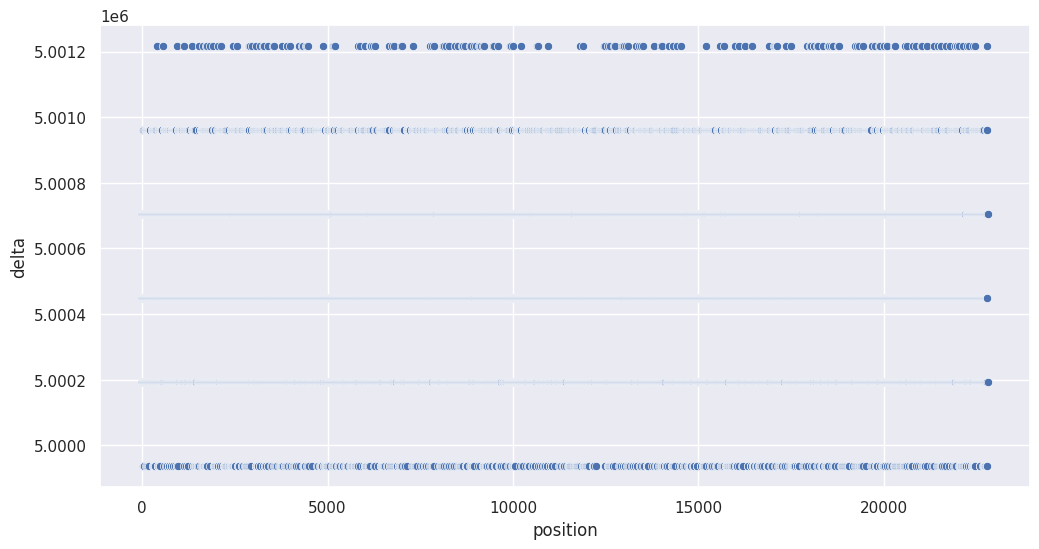

In [69]:
# deltas = np.diff(modified_ts_arr)
# delta_df = pd.DataFrame({'position': np.arange(0, len(deltas)) , 'delta':deltas})
# sns.set_theme(rc={'figure.figsize':(12, 6)})
# sns.scatterplot(data=delta_df, x='position', y='delta')

<Axes: xlabel='delta'>

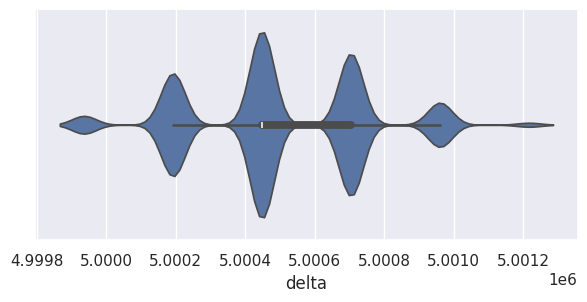

In [70]:
# sns.set_theme(rc={'figure.figsize':(7, 3)})
# sns.violinplot(data=delta_df, x='delta')

In [71]:
# delta_df.describe()

,position,delta
count,22799.00000,2.279900e+04
mean,11399.00000,5.000502e+06
std,6581.64873,2.580947e+02
min,0.00000,4.999936e+06
25%,5699.50000,5.000448e+06
50%,11399.00000,5.000448e+06
75%,17098.50000,5.000704e+06
max,22798.00000,5.001216e+06


### End Section

In [72]:
# df.head(10)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1.413393e+18,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1.413393e+18,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1.413393e+18,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1.413393e+18,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1.413393e+18,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173
5,1.413393e+18,-0.058643,0.024435,0.100531,9.177390,-0.890771,-2.582418
6,1.413393e+18,-0.005585,0.009076,0.113795,9.299973,-1.234003,-2.476179
7,1.413393e+18,0.037001,0.013265,0.100531,9.586000,-0.817221,-2.745862
8,1.413393e+18,0.061436,0.023736,0.091455,9.275456,0.073550,-2.582418
9,1.413393e+18,0.044680,0.017453,0.076794,9.536967,0.498505,-2.688657


In [73]:
df['#timestamp [ns]'] = df['#timestamp [ns]'].apply(lambda x: f"{x:.0f}")

In [74]:
# df.head(10)

,#timestamp [ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
0,1413393212225760512,0.094946,0.020246,0.058643,9.128357,0.106239,-2.606934
1,1413393212230760960,0.058643,0.035605,0.051662,9.422556,1.160454,-2.623279
2,1413393212235761408,-0.011170,0.027925,0.069813,9.398040,1.618097,-2.705001
3,1413393212240761856,-0.072606,0.033510,0.069813,9.496106,0.670121,-2.819412
4,1413393212245762304,-0.092153,0.036303,0.078889,8.989429,-0.130755,-2.713173
5,1413393212250762752,-0.058643,0.024435,0.100531,9.177390,-0.890771,-2.582418
6,1413393212255763200,-0.005585,0.009076,0.113795,9.299973,-1.234003,-2.476179
7,1413393212260763648,0.037001,0.013265,0.100531,9.586000,-0.817221,-2.745862
8,1413393212265764352,0.061436,0.023736,0.091455,9.275456,0.073550,-2.582418
9,1413393212270764544,0.044680,0.017453,0.076794,9.536967,0.498505,-2.688657


In [75]:
if WRITE_FILES:
    filename = f'data_modified_{max_jitter[selection] / 1000000}ms_jitter.csv'
    df.to_csv(working_dir + f'/mav0_euroc/imu0/{filename}', index=False)
    !cp {working_dir}/mav0_euroc/imu0/{filename} {working_dir}/mav0/imu0/{filename}

In [1]:
!jupyter nbconvert --to script Downsample_Perturb_IMU_Data-Copy1.ipynb

[NbConvertApp] Converting notebook Downsample_Perturb_IMU_Data-Copy1.ipynb to script
[NbConvertApp] Writing 3919 bytes to Downsample_Perturb_IMU_Data-Copy1.py
